# Data loading and join test

This notebook tests `src/common/data_loading.py`, which loads the calendar, the two ECCC weather
stations, and the six per-FSA consumption files, then joins them into a single hourly dataset
(one row per FSA x hour).

Use it to validate the join prior to feature engineering: row counts, date coverage, missing
values, and a consumption sanity plot.

In [80]:
# Jupyter's cwd is the notebook's folder, not the repo root, so "from src.common..." below
# needs the repo root on sys.path. This walks up parent folders until it finds requirements.txt
# (which only exists at the repo root) and adds that folder to sys.path.
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (requirements.txt not found)")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

WindowsPath('c:/workspace/CAPSTONE/ontario-electricity-peak-risk')

In [81]:
import pandas as pd

from src.common.data_loading import (
    FSA_STATION_MAP,
    build_all_fsa_dataset,
    build_fsa_hourly_dataset,
    save_interim_dataset,
)

pd.set_option("display.max_columns", 50)

## 1. Single FSA sanity check

Runs the join for a single FSA (M5S, Toronto City station) prior to processing all six.

In [82]:
m5s = build_fsa_hourly_dataset("M5S")
print(m5s.shape)
m5s.head()

(43824, 54)


,fsa,station,timestamp_local,electricity_consumption,premise_count,timestamp_utc,timestamp_toronto,date,year,quarter,month,month_name,week_of_year,day_of_year,day_of_month,hour,hour_group,weekday,weekday_name,is_weekend,is_workday,is_monday,is_friday,season,is_business_hour,...,is_year_end,is_public_holiday,holiday_name,is_day_before_holiday,is_day_after_holiday,days_to_holiday,days_after_holiday,is_long_weekend,is_daylight_saving_time,is_dst_transition_day,is_spring_forward_day,is_fall_back_day,utc_offset_hours,date_index,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,visibility_km
0,M5S,toronto_city,2021-01-01 00:00:00,4186.2,5927,2021-01-01 05:00:00+00:00,2021-01-01 00:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,0,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.000000,1.000000,-0.433884,-0.900969,0.0,1.0,-0.9,69.0,0.0,NaN,NaN
1,M5S,toronto_city,2021-01-01 01:00:00,3868.8,5927,2021-01-01 06:00:00+00:00,2021-01-01 01:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,1,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.258819,0.965926,-0.433884,-0.900969,0.0,1.0,-0.8,71.0,0.0,NaN,NaN
2,M5S,toronto_city,2021-01-01 02:00:00,3652.6,5927,2021-01-01 07:00:00+00:00,2021-01-01 02:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,2,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.500000,0.866025,-0.433884,-0.900969,0.0,1.0,-0.9,69.0,0.0,NaN,NaN
3,M5S,toronto_city,2021-01-01 03:00:00,3538.7,5927,2021-01-01 08:00:00+00:00,2021-01-01 03:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,3,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.707107,0.707107,-0.433884,-0.900969,0.0,1.0,-0.8,74.0,0.0,NaN,NaN
4,M5S,toronto_city,2021-01-01 04:00:00,3417.8,5927,2021-01-01 09:00:00+00:00,2021-01-01 04:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,4,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.866025,0.500000,-0.433884,-0.900969,0.0,1.0,-0.3,75.0,0.0,NaN,NaN


## 2. All 6 FSAs, joined and stacked

This produces the long-format table (one row per FSA x hour) used to train the pooled LightGBM
model.

In [83]:
dataset = build_all_fsa_dataset()
print(dataset.shape)
dataset.head()

(262944, 54)


,fsa,station,timestamp_local,electricity_consumption,premise_count,timestamp_utc,timestamp_toronto,date,year,quarter,month,month_name,week_of_year,day_of_year,day_of_month,hour,hour_group,weekday,weekday_name,is_weekend,is_workday,is_monday,is_friday,season,is_business_hour,...,is_year_end,is_public_holiday,holiday_name,is_day_before_holiday,is_day_after_holiday,days_to_holiday,days_after_holiday,is_long_weekend,is_daylight_saving_time,is_dst_transition_day,is_spring_forward_day,is_fall_back_day,utc_offset_hours,date_index,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,visibility_km
0,L4T,toronto_intl_a,2021-01-01 00:00:00,10276.6,8651,2021-01-01 05:00:00+00:00,2021-01-01 00:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,0,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.000000,1.000000,-0.433884,-0.900969,0.0,1.0,-2.4,74.0,NaN,3.0,24.1
1,L4T,toronto_intl_a,2021-01-01 01:00:00,9585.1,8651,2021-01-01 06:00:00+00:00,2021-01-01 01:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,1,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.258819,0.965926,-0.433884,-0.900969,0.0,1.0,-1.9,72.0,NaN,3.0,24.1
2,L4T,toronto_intl_a,2021-01-01 02:00:00,9015.5,8651,2021-01-01 07:00:00+00:00,2021-01-01 02:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,2,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.500000,0.866025,-0.433884,-0.900969,0.0,1.0,-2.3,75.0,NaN,5.0,24.1
3,L4T,toronto_intl_a,2021-01-01 03:00:00,8593.1,8651,2021-01-01 08:00:00+00:00,2021-01-01 03:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,3,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.707107,0.707107,-0.433884,-0.900969,0.0,1.0,-3.5,82.0,NaN,4.0,24.1
4,L4T,toronto_intl_a,2021-01-01 04:00:00,8353.5,8651,2021-01-01 09:00:00+00:00,2021-01-01 04:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,4,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.866025,0.500000,-0.433884,-0.900969,0.0,1.0,-3.2,83.0,NaN,5.0,24.1


## 3. Row counts and date coverage per FSA

Prior to aggregation, M5S and M5R appeared to have roughly half as many rows as the other FSAs.
This was an artifact of the raw consumption files, which record separate rows per customer_type
and price_plan; once summed into one row per FSA-hour, all six FSAs show identical full coverage.
Confirmed below.

In [84]:
summary = dataset.groupby("fsa").agg(
    rows=("timestamp_local", "count"),
    start=("timestamp_local", "min"),
    end=("timestamp_local", "max"),
)
summary

,rows,start,end
fsa,,,
L4T,43824,2021-01-01,2025-12-31 23:00:00
M5R,43824,2021-01-01,2025-12-31 23:00:00
M5S,43824,2021-01-01,2025-12-31 23:00:00
M6G,43824,2021-01-01,2025-12-31 23:00:00
M9R,43824,2021-01-01,2025-12-31 23:00:00
M9W,43824,2021-01-01,2025-12-31 23:00:00


## 4. Missing values per column

`electricity_consumption` and the calendar columns contain no missing values. `temperature_c` and
`relative_humidity_pct` are missing in under 0.1% of rows, attributable to a small number of
short station outages. `precipitation_mm`, `wind_speed_kmh`, and `visibility_km` are missing in
approximately half the rows: each FSA only receives the variables reported by its assigned
station (e.g., no `wind_speed_kmh` for Toronto City FSAs). This pattern is expected, not a
defect.

In [85]:
dataset.isna().mean().sort_values(ascending=False).to_frame("pct_missing")

,pct_missing
holiday_name,0.973165
precipitation_mm,0.500468
visibility_km,0.500080
wind_speed_kmh,0.500068
relative_humidity_pct,0.000548
temperature_c,0.000536
timestamp_toronto,0.000000
date,0.000000
year,0.000000
quarter,0.000000


## 5. FSA to weather station assignment used

In [86]:
pd.Series(FSA_STATION_MAP, name="station").to_frame()

,station
M5S,toronto_city
M5R,toronto_city
M6G,toronto_city
L4T,toronto_intl_a
M9W,toronto_intl_a
M9R,toronto_intl_a


## 6. Consumption sanity plot

Average consumption by hour of day, per FSA. The expected pattern is a plausible daily shape
(higher consumption during morning/evening peak windows), rather than anything indicating a
broken join.

The six FSAs separate into two distinct tiers: L4T, M6G, and M9W range from approximately
9,500-15,000 kWh, while M5R, M9R, and M5S are lower, ranging from approximately 3,000-9,600 kWh.
M5S is consistently the smallest of the six. Both tiers follow the same shape: an overnight dip
(3-5am), a rise through the morning, a daytime plateau, and a peak around 17-19h before tapering
off. The absence of flat lines or abrupt jumps supports the validity of the join. The cause of
the two-tier split warrants further investigation in the EDA notebook (premise_count, zone type,
etc.). Flagged here, not answered.

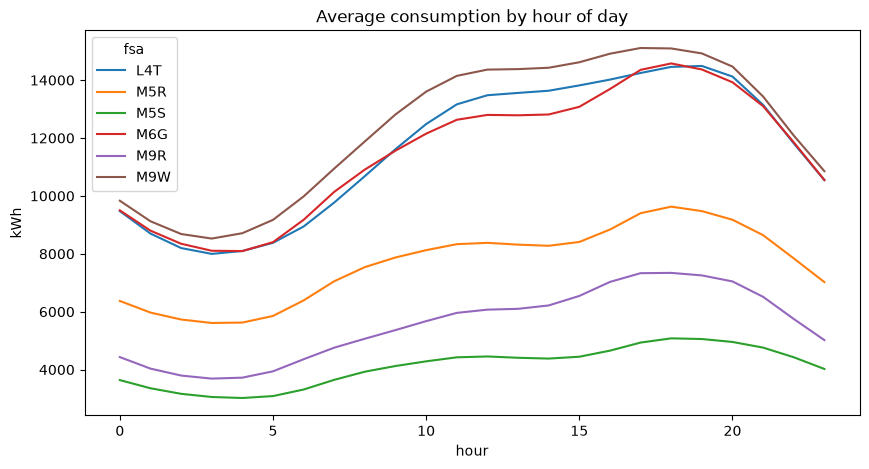

In [87]:
import matplotlib.pyplot as plt

hourly_profile = dataset.groupby(["fsa", "hour"])["electricity_consumption"].mean().unstack("fsa")
hourly_profile.plot(figsize=(10, 5), title="Average consumption by hour of day")
plt.ylabel("kWh")
plt.show()

## 7. Save the joined dataset to `data/interim/`

Run this step only once the preceding checks pass: it writes the contents of `dataset` to disk
without performing any validation of its own. The correctness of the resulting parquet file
therefore depends entirely on sections 3-6: full row counts and coverage per FSA, missing values
matching expectations, and a correct station mapping and consumption plot. The dataset is saved
as parquet rather than CSV because it is columnar (smaller file size, faster read time) and
preserves dtypes such as datetimes exactly, allowing downstream notebooks to call
`pd.read_parquet()` directly instead of re-running the full join.

In [88]:
output_path = save_interim_dataset(dataset)
output_path

WindowsPath('C:/workspace/CAPSTONE/ontario-electricity-peak-risk/data/interim/fsa_hourly_master.parquet')

## 8. Confirm the saved file matches what section 7 describes

Reads `fsa_hourly_master.parquet` back from disk and compares it against `dataset` to confirm the
round trip preserves row count, columns, and dtypes exactly, including `timestamp_local` and
`timestamp_utc` as proper datetimes rather than strings.

In [89]:
reloaded = pd.read_parquet(output_path)

print(reloaded.shape, reloaded.shape == dataset.shape)
print(reloaded.dtypes.equals(dataset.dtypes))
reloaded.head(10)

(262944, 54) True
True


,fsa,station,timestamp_local,electricity_consumption,premise_count,timestamp_utc,timestamp_toronto,date,year,quarter,month,month_name,week_of_year,day_of_year,day_of_month,hour,hour_group,weekday,weekday_name,is_weekend,is_workday,is_monday,is_friday,season,is_business_hour,...,is_year_end,is_public_holiday,holiday_name,is_day_before_holiday,is_day_after_holiday,days_to_holiday,days_after_holiday,is_long_weekend,is_daylight_saving_time,is_dst_transition_day,is_spring_forward_day,is_fall_back_day,utc_offset_hours,date_index,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,visibility_km
0,L4T,toronto_intl_a,2021-01-01 00:00:00,10276.6,8651,2021-01-01 05:00:00+00:00,2021-01-01 00:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,0,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.000000,1.000000e+00,-0.433884,-0.900969,0.0,1.0,-2.4,74.0,NaN,3.0,24.1
1,L4T,toronto_intl_a,2021-01-01 01:00:00,9585.1,8651,2021-01-01 06:00:00+00:00,2021-01-01 01:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,1,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.258819,9.659258e-01,-0.433884,-0.900969,0.0,1.0,-1.9,72.0,NaN,3.0,24.1
2,L4T,toronto_intl_a,2021-01-01 02:00:00,9015.5,8651,2021-01-01 07:00:00+00:00,2021-01-01 02:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,2,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.500000,8.660254e-01,-0.433884,-0.900969,0.0,1.0,-2.3,75.0,NaN,5.0,24.1
3,L4T,toronto_intl_a,2021-01-01 03:00:00,8593.1,8651,2021-01-01 08:00:00+00:00,2021-01-01 03:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,3,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.707107,7.071068e-01,-0.433884,-0.900969,0.0,1.0,-3.5,82.0,NaN,4.0,24.1
4,L4T,toronto_intl_a,2021-01-01 04:00:00,8353.5,8651,2021-01-01 09:00:00+00:00,2021-01-01 04:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,4,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.866025,5.000000e-01,-0.433884,-0.900969,0.0,1.0,-3.2,83.0,NaN,5.0,24.1
5,L4T,toronto_intl_a,2021-01-01 05:00:00,8334.4,8651,2021-01-01 10:00:00+00:00,2021-01-01 05:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,5,Night,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.965926,2.588190e-01,-0.433884,-0.900969,0.0,1.0,-2.5,80.0,NaN,10.0,24.1
6,L4T,toronto_intl_a,2021-01-01 06:00:00,8499.5,8651,2021-01-01 11:00:00+00:00,2021-01-01 06:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,6,Morning,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.0,1.0,-2.5,85.0,NaN,0.0,24.1
7,L4T,toronto_intl_a,2021-01-01 07:00:00,8784.2,8651,2021-01-01 12:00:00+00:00,2021-01-01 07:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,7,Morning,4,Friday,0,0,0,1,Winter,0,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.965926,-2.588190e-01,-0.433884,-0.900969,0.0,1.0,-2.2,84.0,NaN,3.0,24.1
8,L4T,toronto_intl_a,2021-01-01 08:00:00,9313.2,8651,2021-01-01 13:00:00+00:00,2021-01-01 08:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,8,Morning,4,Friday,0,0,0,1,Winter,1,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.866025,-5.000000e-01,-0.433884,-0.900969,0.0,1.0,-1.7,82.0,NaN,0.0,24.1
9,L4T,toronto_intl_a,2021-01-01 09:00:00,10062.2,8651,2021-01-01 14:00:00+00:00,2021-01-01 09:00:00-05:00,2021-01-01,2021,1,1,January,53,1,1,9,Morning,4,Friday,0,0,0,1,Winter,1,...,0,1,New Year's Day,0,0,0,0,1,0,0,0,0,-5,0,0.707107,-7.071068e-01,-0.433884,-0.900969,0.0,1.0,-0.3,75.0,NaN,8.0,24.1
